# Reversibility main effect

Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import chi2_contingency
from statsmodels.stats.contingency_tables import Table

import seaborn as sns

## Overall Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [2]:
subgroup_theoretical = pd.read_csv("../../data/processed/subgroup_theoretical.csv")

1. Contingency Table

In [3]:
contingency = pd.crosstab(
    subgroup_theoretical["Consequent_Reversibility"],
    subgroup_theoretical["Response_Full"]
)

contingency

Response_Full,L1_transfer,L2_other,correct
Consequent_Reversibility,,,
No,37,10,19
Yes,59,28,42


2. Proportions

In [4]:
proportions = pd.crosstab(
    subgroup_theoretical["Consequent_Reversibility"],
    subgroup_theoretical["Response_Full"],
    normalize="index"
)

proportions

Response_Full,L1_transfer,L2_other,correct
Consequent_Reversibility,,,
No,0.560606,0.151515,0.287879
Yes,0.457364,0.217054,0.325581


3. Chi-Square Test

In [5]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 2.106
p-value: 0.3489
Degrees of freedom: 2


There is no evidence that response distribution differs across reversibility conditions.

4. Expected Counts

In [6]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

Response_Full,L1_transfer,L2_other,correct
Consequent_Reversibility,,,
No,32.492308,12.861538,20.646154
Yes,63.507692,25.138462,40.353846


In [7]:
print(expected_df < 5)

Response_Full             L1_transfer  L2_other  correct
Consequent_Reversibility                                
No                              False     False    False
Yes                             False     False    False


There aren't any groups with fewer than 5 observations.

5. Cramér's V

In [8]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.104


V = 0.104: the effect size is small

6. Standardized Residuals

In [9]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

Response_Full,L1_transfer,L2_other,correct
Consequent_Reversibility,,,
No,0.790795,-0.797909,-0.362285
Yes,-0.565641,0.570729,0.259136


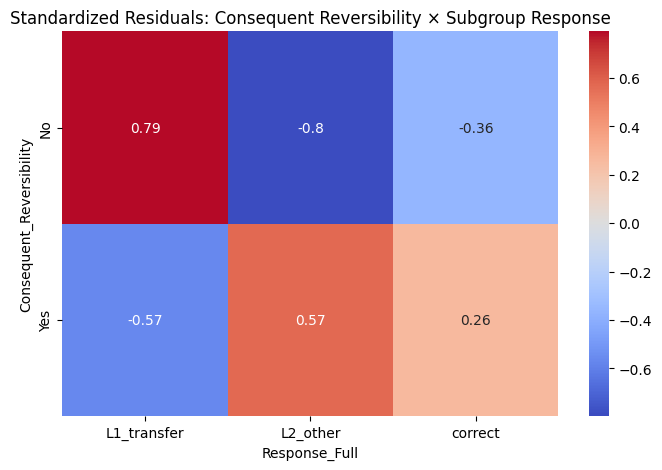

In [10]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Consequent Reversibility × Subgroup Response")
plt.show()

7. Interpretation

Interpretation:

- χ² significant / not significant
- Effect size
- Cells driving the association
- Does this support the reversibility hypothesis?
- What remains unexplained?

Although residuals suggest a tendency for irreversible scenarios to elicit more L1-transfer responses than expected and reversible scenarios to elicit fewer, the overall association between Consequent Reversibility and response type is weak and non-significant (χ²(2)=2.11, p=.35, Cramér’s V=.10).

Therefore, Consequent Reversibility on its own cannot account for response distribution in the theoretical subgroup.

This suggests that the effect of reversibility may depend on additional contextual variables like Agency and/or Goal Type.

# Actors Subgroup:

1. Contigency Table
2. Proportions
3. Chi-Square Test
4. Expected Counts
5. Cramér's V
6. Standardized Residuals
7. Interpretation

Read data

In [11]:
subgroup_actors = subgroup_theoretical[subgroup_theoretical["Focus"] == "I"].copy()

1. Contingency Table

In [12]:
contingency = pd.crosstab(
    subgroup_actors["Consequent_Reversibility"],
    subgroup_actors["Response_Full"]
)

contingency

Response_Full,L1_transfer,L2_other,correct
Consequent_Reversibility,,,
No,18,9,13
Yes,35,15,27


2. Proportions

In [13]:
proportions = pd.crosstab(
    subgroup_actors["Consequent_Reversibility"],
    subgroup_actors["Response_Full"],
    normalize="index"
)

proportions

Response_Full,L1_transfer,L2_other,correct
Consequent_Reversibility,,,
No,0.450000,0.225000,0.325000
Yes,0.454545,0.194805,0.350649


3. Chi-Square Test

In [14]:
chi2, p, dof, expected = chi2_contingency(contingency)

print(f"Chi-square: {chi2:.3f}")
print(f"p-value: {p:.4f}")
print(f"Degrees of freedom: {dof}")

Chi-square: 0.169
p-value: 0.9190
Degrees of freedom: 2


4. Expected Counts

In [15]:
expected_df = pd.DataFrame(
    expected,
    index=contingency.index,
    columns=contingency.columns
)

expected_df

Response_Full,L1_transfer,L2_other,correct
Consequent_Reversibility,,,
No,18.119658,8.205128,13.675214
Yes,34.880342,15.794872,26.324786


In [16]:
print(expected_df < 5)

Response_Full             L1_transfer  L2_other  correct
Consequent_Reversibility                                
No                              False     False    False
Yes                             False     False    False


There are no groups with fewer than  observations

5. Cramér's V

In [17]:
n = contingency.values.sum()

cramers_v = np.sqrt(
    chi2 / (n * (min(contingency.shape) - 1))
)

print(f"Cramér's V: {cramers_v:.3f}")

Cramér's V: 0.038


V = 0.038: the effect size is tiny, even smaller than the effect size for the overal subgroup (V = 0.104)

6. Standardized Residuals

In [18]:
residuals = (
    contingency - expected
) / np.sqrt(expected)

residuals

Response_Full,L1_transfer,L2_other,correct
Consequent_Reversibility,,,
No,-0.028110,0.277495,-0.182589
Yes,0.020261,-0.200004,0.131601


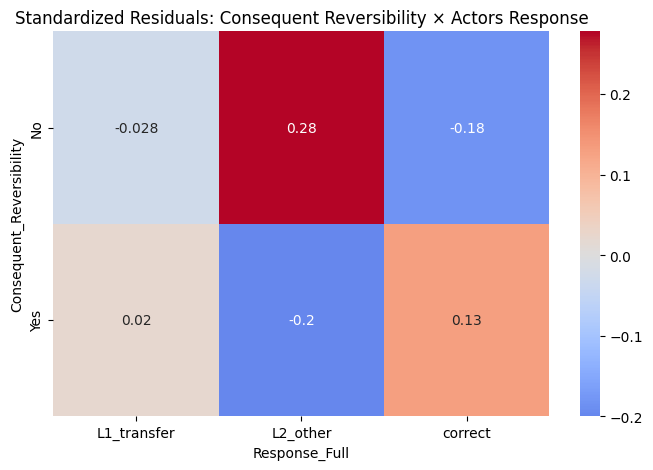

In [19]:
plt.figure(figsize=(8, 5))

sns.heatmap(
    residuals,
    annot=True,
    cmap="coolwarm",
    center=0
)

plt.title("Standardized Residuals: Consequent Reversibility × Actors Response")
plt.show()

7. Interpretation

Neither the overall theoretical subgroup nor the actors subgroup showed a significant association between Consequent Reversibility and response type. Effect sizes were small to negligible (V = .104 and V = .038 respectively). Standardized residuals revealed no meaningful departures from expected frequencies among actors. These findings indicate that reversibility alone does not account for response choice and suggest that any potential influence of reversibility may emerge only in interaction with other theoretically relevant variables such as Agency and Goal Type. 

**Consequent Reversability is not a main effect.**
